# 📊 Visualización desde MySQL — Northwind
### Taller de Programación

---

Combinamos lo visto en las dos clases anteriores:
- Consultamos datos desde MySQL con `query()`
- Visualizamos los resultados con Matplotlib y Seaborn

Usamos la vista `vw_orden_detalle` que ya resuelve todos los JOINs.

## 0. Conexión

In [1]:
!pip install mysql-connector-python

In [2]:

import sqlite3
import urllib.request
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='tab10')

# ── Descargar Northwind en SQLite si no existe ─────────────────────
DB_PATH = 'northwind.db'
DB_URL  = 'https://raw.githubusercontent.com/jpwhite3/northwind-SQLite3/master/dist/northwind.db'

if not os.path.exists(DB_PATH):
    print('Descargando Northwind SQLite...')
    urllib.request.urlretrieve(DB_URL, DB_PATH)
    print(f'✅ Descargado en: {os.path.abspath(DB_PATH)}')
else:
    print(f'✅ Base encontrada en: {os.path.abspath(DB_PATH)}')

conn = sqlite3.connect(DB_PATH)
print('✅ Conexión abierta (SQLite)')

def query(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params)

# Verificar tablas disponibles
tablas = query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
print(f"\nTablas disponibles: {tablas['name'].tolist()}")


✅ Base encontrada en: /content/northwind.db
✅ Conexión abierta (SQLite)

Tablas disponibles: ['Categories', 'CustomerCustomerDemo', 'CustomerDemographics', 'Customers', 'EmployeeTerritories', 'Employees', 'Order Details', 'Orders', 'Products', 'Regions', 'Shippers', 'Suppliers', 'Territories', 'sqlite_sequence']


---
## 1. Ingresos por país

Primero consultamos, luego visualizamos.

In [3]:
ing_pais = query("""
    SELECT  c.Country                                        AS Pais,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Ingresos,
            COUNT(DISTINCT o.OrderID)                        AS Pedidos
    FROM    Orders o
    JOIN    Customers c  ON o.CustomerID = c.CustomerID
    JOIN   'Order Details' od ON o.OrderID = od.OrderID
    WHERE   c.Country IS NOT NULL
    GROUP BY c.Country
    ORDER BY Ingresos DESC
""")

ing_pais.head()


,Pais,Ingresos,Pedidos
0,USA,62601564.84,2280
1,France,53323305.76,1909
2,Germany,51195766.82,1895
3,Brazil,45801779.28,1659
4,UK,33959254.80,1234


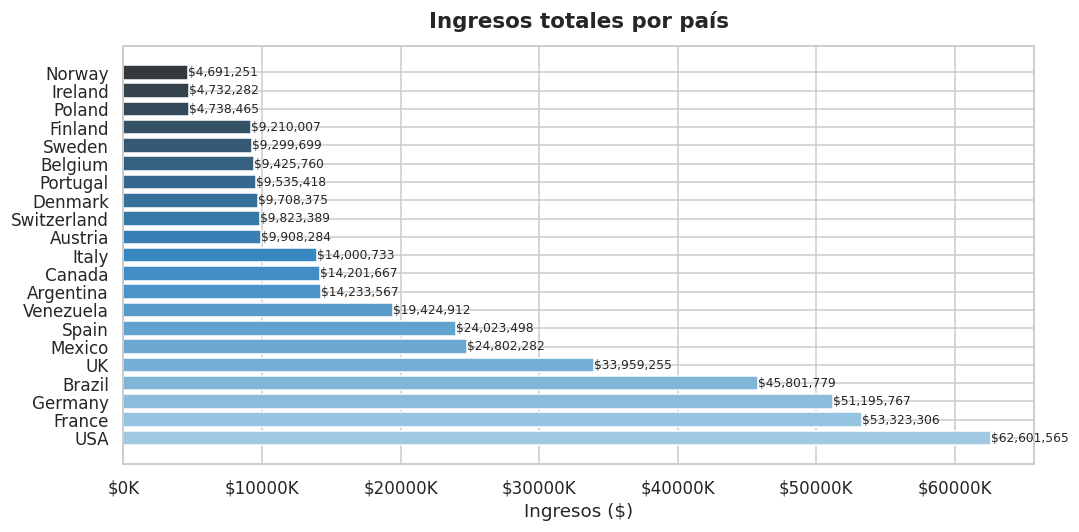

In [4]:
plt.figure(figsize=(10, 5))
bars = plt.barh(ing_pais['Pais'], ing_pais['Ingresos'],
                color=sns.color_palette('Blues_d', len(ing_pais)))

for bar in bars:
    w = bar.get_width()
    plt.text(w + 500, bar.get_y() + bar.get_height() / 2,
             f'${w:,.0f}', va='center', fontsize=8)

plt.title('Ingresos totales por país', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Ingresos ($)')
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 2. Ingresos por categoría de producto

In [5]:
ing_cat = query("""
    SELECT  cat.CategoryName                                  AS Categoria,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Ingresos
    FROM   'Order Details' od
    JOIN    Products p   ON od.ProductID  = p.ProductID
    JOIN    Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
    ORDER BY Ingresos DESC
""")

ing_cat

,Categoria,Ingresos
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


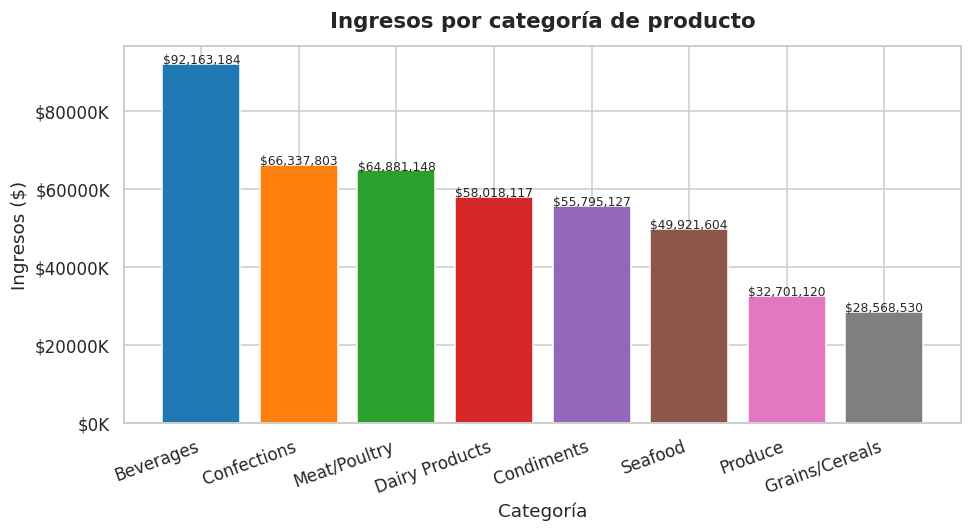

In [6]:
plt.figure(figsize=(9, 5))
bars = plt.bar(ing_cat['Categoria'], ing_cat['Ingresos'],
               color=sns.color_palette('tab10', len(ing_cat)),
               edgecolor='white')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 500,
             f'${h:,.0f}', ha='center', fontsize=8)

plt.title('Ingresos por categoría de producto', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Categoría')
plt.ylabel('Ingresos ($)')
plt.xticks(rotation=20, ha='right')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 3. Evolución mensual de ingresos

In [7]:
ing_mes = query("""
    SELECT  strftime('%Y-%m', o.OrderDate)                    AS Mes,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Ingresos,
            COUNT(DISTINCT o.OrderID)                         AS Pedidos
    FROM    Orders o
    JOIN   'Order Details' od ON o.OrderID = od.OrderID
    GROUP BY Mes
    ORDER BY Mes
""")

ing_mes

,Mes,Ingresos,Pedidos
0,2012-07,2066219.40,69
1,2012-08,3556875.79,122
2,2012-09,3440144.98,119
3,2012-10,3201529.96,111
4,2012-11,2980494.74,105
...,...,...,...
131,2023-06,3071787.73,103
132,2023-07,3350337.36,117
133,2023-08,3293158.67,110
134,2023-09,3544698.51,119


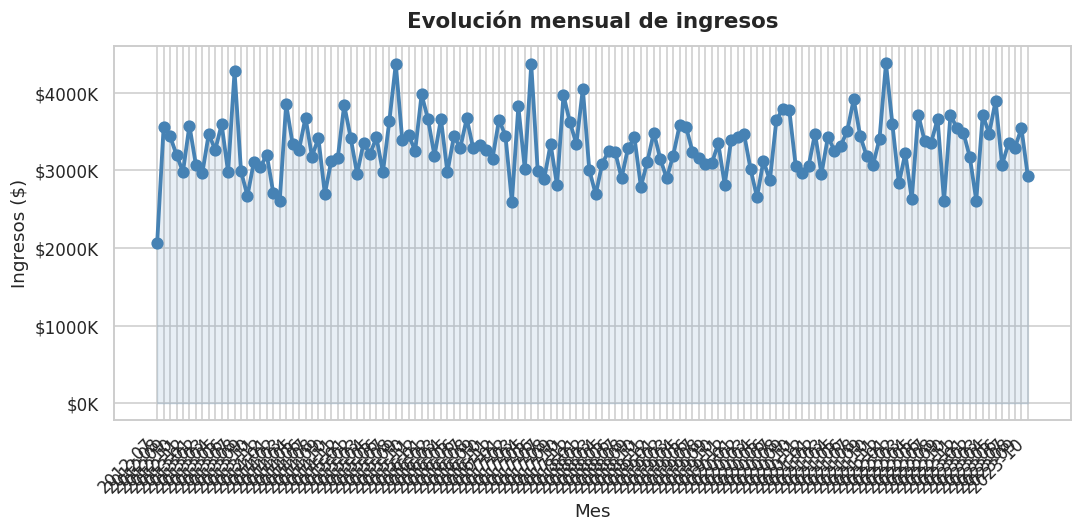

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(ing_mes['Mes'], ing_mes['Ingresos'],
         marker='o', linewidth=2.5, color='steelblue', markersize=7)
plt.fill_between(ing_mes['Mes'], ing_mes['Ingresos'],
                 alpha=0.12, color='steelblue')

plt.title('Evolución mensual de ingresos', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Ingresos ($)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

## 4. Ranking de empleados por ingresos

In [9]:
ing_emp = query("""
    SELECT  e.FirstName || ' ' || e.LastName          AS Empleado,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Ingresos,
            COUNT(DISTINCT o.OrderID)                  AS Pedidos
    FROM    Orders o
    JOIN    Employees e  ON o.EmployeeID = e.EmployeeID
    JOIN   'Order Details' od ON o.OrderID = od.OrderID
    GROUP BY e.EmployeeID
    ORDER BY Ingresos DESC
""")

ing_emp

,Empleado,Ingresos,Pedidos
0,Margaret Peacock,51488395.20,1908
1,Steven Buchanan,51386459.10,1804
2,Janet Leverling,50445573.76,1846
3,Nancy Davolio,49659423.23,1846
4,Robert King,49651899.30,1789
5,Laura Callahan,49281136.81,1798
6,Michael Suyama,49139966.56,1754
7,Anne Dodsworth,49019678.44,1766
8,Andrew Fuller,48314100.77,1771


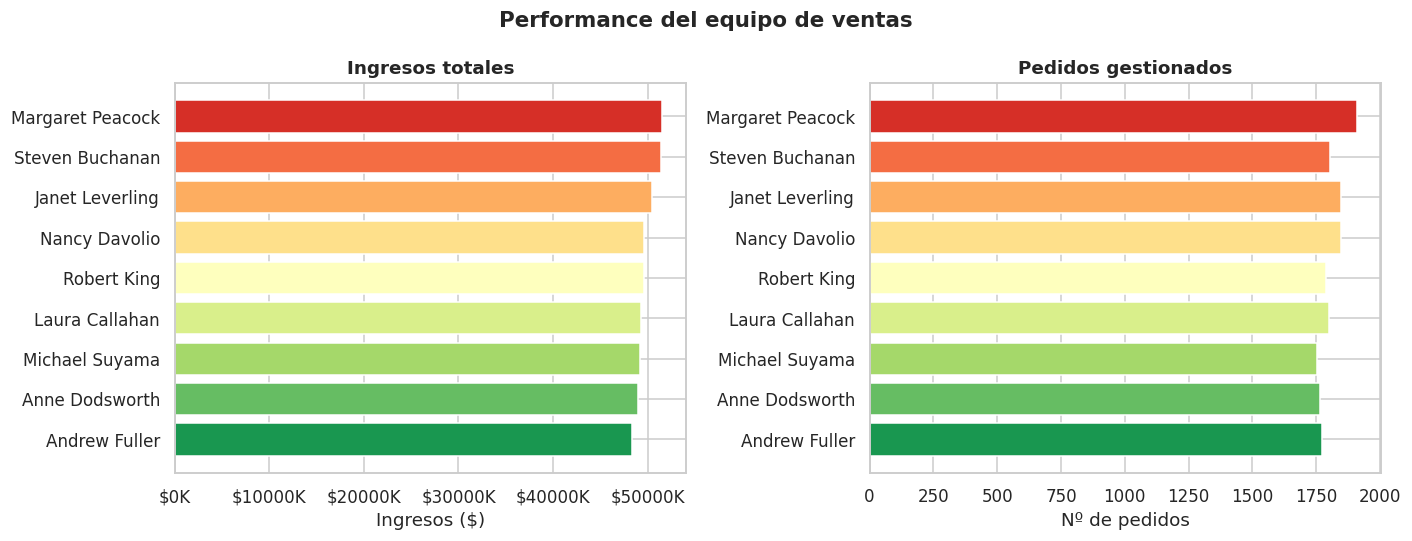

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Performance del equipo de ventas', fontsize=14, fontweight='bold')

# Ingresos por empleado
colores = sns.color_palette('RdYlGn', len(ing_emp))[::-1]
axes[0].barh(ing_emp['Empleado'][::-1], ing_emp['Ingresos'][::-1],
             color=colores, edgecolor='white')
axes[0].set_title('Ingresos totales', fontweight='bold')
axes[0].set_xlabel('Ingresos ($)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Pedidos por empleado
axes[1].barh(ing_emp['Empleado'][::-1], ing_emp['Pedidos'][::-1],
             color=colores, edgecolor='white')
axes[1].set_title('Pedidos gestionados', fontweight='bold')
axes[1].set_xlabel('Nº de pedidos')

plt.tight_layout()
plt.show()

## 5. Distribución del ticket por pedido

In [11]:
ticket = query("""
    SELECT  o.OrderID,
            c.Country                                         AS Pais,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS TicketPedido
    FROM    Orders o
    JOIN    Customers c  ON o.CustomerID = c.CustomerID
    JOIN   'Order Details' od ON o.OrderID = od.OrderID
    WHERE   c.Country IS NOT NULL
    GROUP BY o.OrderID, c.Country
""")

# Top 6 países por cantidad de pedidos
top_paises = ticket['Pais'].value_counts().head(6).index.tolist()
ticket_top = ticket[ticket['Pais'].isin(top_paises)]


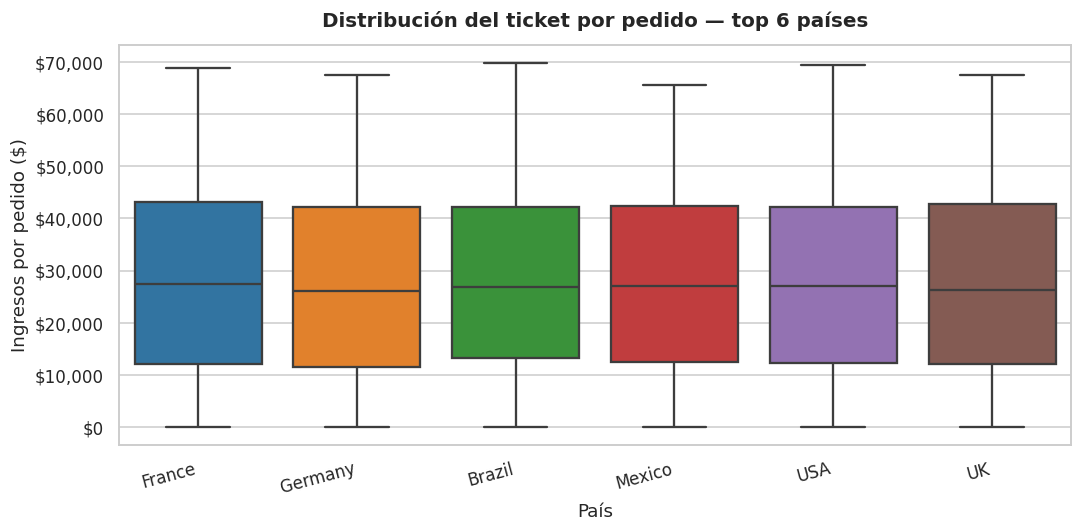

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=ticket_top, x='Pais', y='TicketPedido',
            hue='Pais', legend=False, linewidth=1.5)

plt.title('Distribución del ticket por pedido — top 6 países',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel('País')
plt.ylabel('Ingresos por pedido ($)')
plt.xticks(rotation=15, ha='right')
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## ✏️ Ejercicios

**Ejercicio 1.** Consultá los ingresos por categoría **y por mes**. Graficá las líneas de evolución mensual, una por categoría.

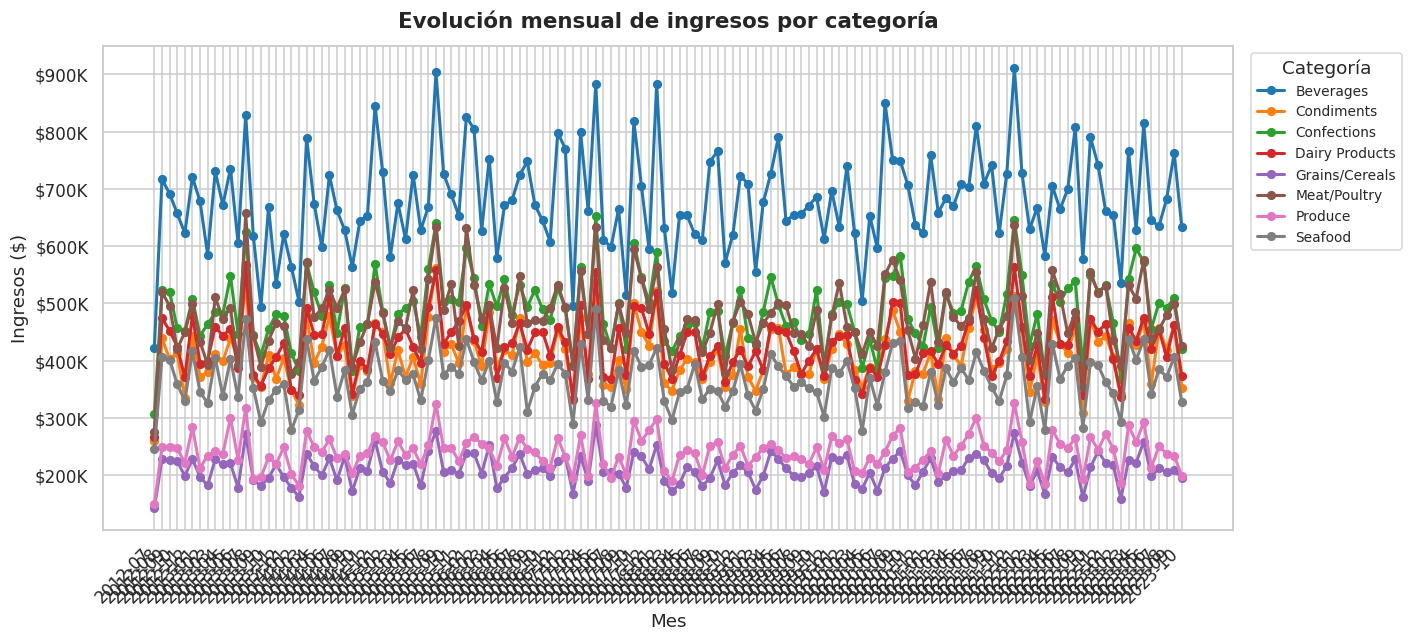


=== Ingresos totales por categoría (suma del período) ===
Categoria
Beverages         $92,163,184
Confections       $66,337,803
Meat/Poultry      $64,881,148
Dairy Products    $58,018,117
Condiments        $55,795,127
Seafood           $49,921,604
Produce           $32,701,120
Grains/Cereals    $28,568,530


In [13]:

# Ejercicio 1 — Ingresos por categoría y mes, una línea por categoría

ing_cat_mes = query("""
    SELECT  strftime('%Y-%m', o.OrderDate)                    AS Mes,
            cat.CategoryName                                  AS Categoria,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Ingresos
    FROM    Orders o
    JOIN   'Order Details' od ON o.OrderID    = od.OrderID
    JOIN    Products p        ON od.ProductID  = p.ProductID
    JOIN    Categories cat    ON p.CategoryID  = cat.CategoryID
    GROUP BY Mes, cat.CategoryName
    ORDER BY Mes
""")

# Pivot: filas = Mes, columnas = Categoria
pivot = ing_cat_mes.pivot(index='Mes', columns='Categoria', values='Ingresos').fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
paleta = sns.color_palette('tab10', len(pivot.columns))

for col, color in zip(pivot.columns, paleta):
    ax.plot(pivot.index, pivot[col], marker='o', linewidth=2,
            markersize=5, label=col, color=color)

ax.set_title('Evolución mensual de ingresos por categoría',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
ax.legend(title='Categoría', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\n=== Ingresos totales por categoría (suma del período) ===")
print(pivot.sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}').to_string())


**Ejercicio 2.** Calculá el **ticket promedio por empleado** (ingresos / pedidos). ¿Coincide el ranking con el de ingresos totales?

=== Ranking por ingresos totales ===
        Empleado    Ingresos  Pedidos
Margaret Peacock 51488395.20     1908
 Steven Buchanan 51386459.10     1804
 Janet Leverling 50445573.76     1846
   Nancy Davolio 49659423.23     1846
     Robert King 49651899.30     1789
  Laura Callahan 49281136.81     1798
  Michael Suyama 49139966.56     1754
  Anne Dodsworth 49019678.44     1766
   Andrew Fuller 48314100.77     1771

=== Ranking por ticket promedio ===
        Empleado  TicketPromedio  Pedidos
 Steven Buchanan        28484.73     1804
  Michael Suyama        28015.94     1754
  Anne Dodsworth        27757.46     1766
     Robert King        27754.00     1789
  Laura Callahan        27408.86     1798
 Janet Leverling        27326.96     1846
   Andrew Fuller        27280.69     1771
Margaret Peacock        26985.53     1908
   Nancy Davolio        26901.10     1846


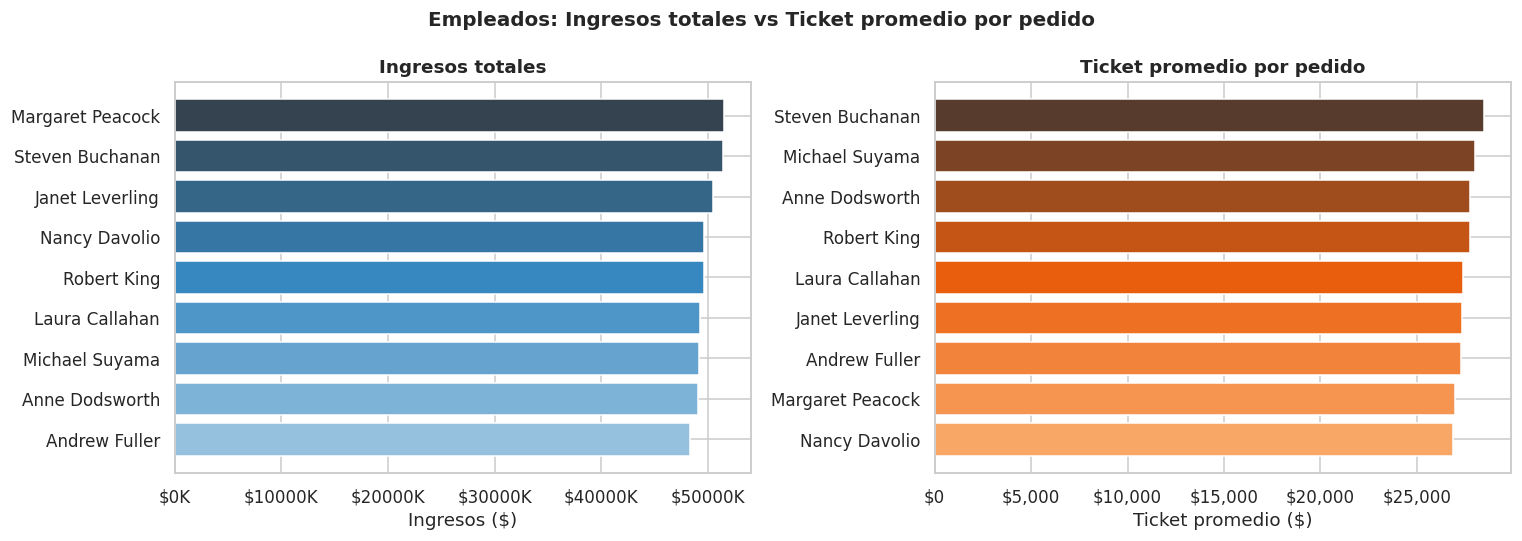

In [14]:

# Ejercicio 2 — Ticket promedio por empleado (ingresos / pedidos)

# Reutilizamos ing_emp que ya tiene Ingresos y Pedidos
ing_emp2 = ing_emp.copy()
ing_emp2['TicketPromedio'] = (ing_emp2['Ingresos'] / ing_emp2['Pedidos']).round(2)
ing_emp2 = ing_emp2.sort_values('TicketPromedio', ascending=False)

print("=== Ranking por ingresos totales ===")
print(ing_emp[['Empleado', 'Ingresos', 'Pedidos']].to_string(index=False))
print("\n=== Ranking por ticket promedio ===")
print(ing_emp2[['Empleado', 'TicketPromedio', 'Pedidos']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Empleados: Ingresos totales vs Ticket promedio por pedido',
             fontsize=13, fontweight='bold')

colores_ing = sns.color_palette('Blues_d', len(ing_emp))
colores_tkt = sns.color_palette('Oranges_d', len(ing_emp2))

# Panel izquierdo: ingresos totales
axes[0].barh(ing_emp['Empleado'][::-1], ing_emp['Ingresos'][::-1],
             color=colores_ing, edgecolor='white')
axes[0].set_title('Ingresos totales', fontweight='bold')
axes[0].set_xlabel('Ingresos ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Panel derecho: ticket promedio
axes[1].barh(ing_emp2['Empleado'][::-1], ing_emp2['TicketPromedio'][::-1],
             color=colores_tkt, edgecolor='white')
axes[1].set_title('Ticket promedio por pedido', fontweight='bold')
axes[1].set_xlabel('Ticket promedio ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


**Ejercicio 3.** Graficá un heatmap con los ingresos por **categoría × país** (filas = categoría, columnas = país).

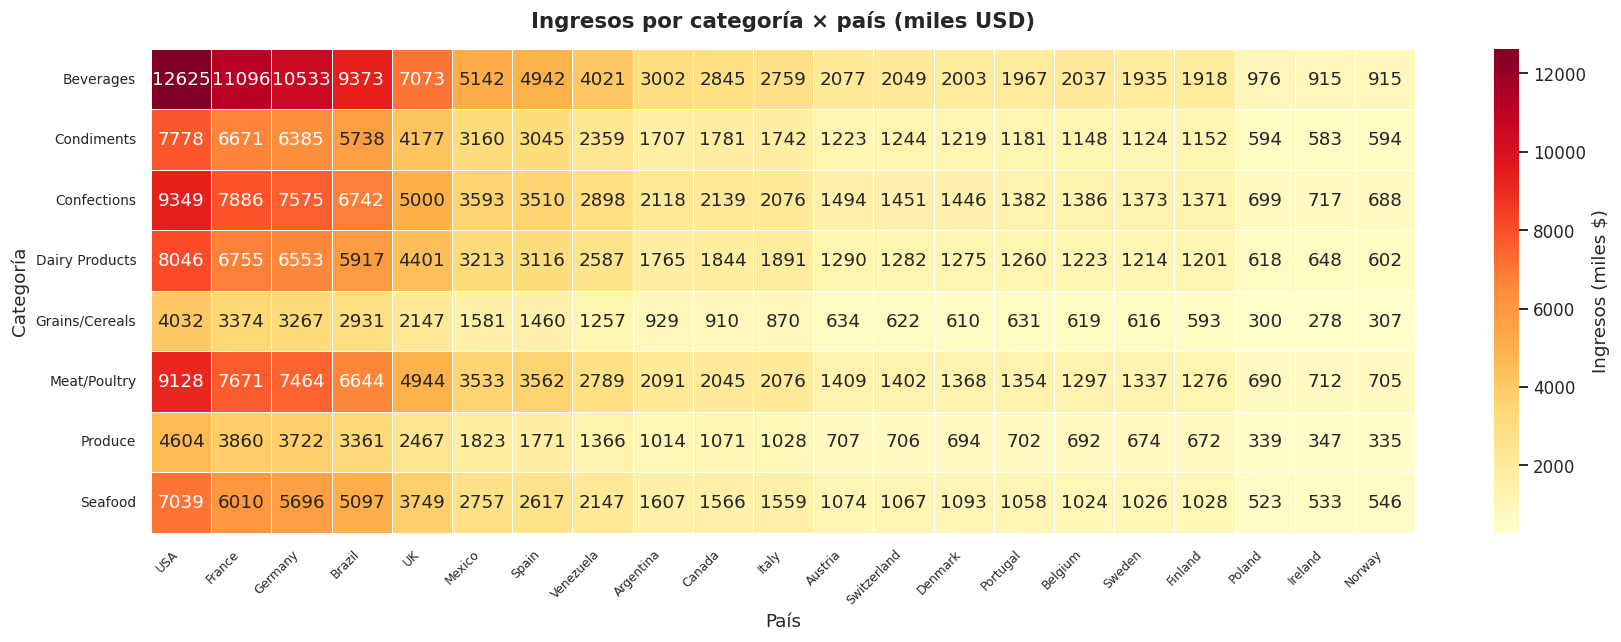


=== Top 5 países por ingresos totales ===
Pais
USA        $62,601,565
France     $53,323,306
Germany    $51,195,767
Brazil     $45,801,779
UK         $33,959,255


In [15]:

# Ejercicio 3 — Heatmap: ingresos por categoría × país

ing_cat_pais = query("""
    SELECT  cat.CategoryName                                  AS Categoria,
            c.Country                                         AS Pais,
            ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS Ingresos
    FROM    Orders o
    JOIN    Customers c       ON o.CustomerID  = c.CustomerID
    JOIN   'Order Details' od ON o.OrderID    = od.OrderID
    JOIN    Products p        ON od.ProductID  = p.ProductID
    JOIN    Categories cat    ON p.CategoryID  = cat.CategoryID
    WHERE   c.Country IS NOT NULL
    GROUP BY cat.CategoryName, c.Country
    ORDER BY Categoria, Pais
""")

# Pivot: filas = Categoría, columnas = País
pivot_hm = ing_cat_pais.pivot(index='Categoria', columns='Pais', values='Ingresos').fillna(0)
# Ordenar columnas de mayor a menor ingreso total
pivot_hm = pivot_hm[pivot_hm.sum().sort_values(ascending=False).index]

plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_hm / 1000,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Ingresos (miles $)'}
)
plt.title('Ingresos por categoría × país (miles USD)',
          fontsize=14, fontweight='bold', pad=14)
plt.xlabel('País')
plt.ylabel('Categoría')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n=== Top 5 países por ingresos totales ===")
print(pivot_hm.sum().sort_values(ascending=False).head(5)
      .apply(lambda x: f'${x:,.0f}').to_string())


---
## Cierre de conexión

In [16]:
conn.close()
print('🔒 Conexión cerrada')

🔒 Conexión cerrada
